import


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

ส่วนที่ 1: การเตรียมข้อมูลและจัดการค่าสูญหาย (Data Cleaning)
ข้อความที่จะใส่ (Text Cell):

1. การเตรียมข้อมูลและจัดการค่าสูญหาย (Data Cleaning & Preprocessing)
ในขั้นตอนนี้ เราทำการตรวจสอบคุณภาพของข้อมูล (Data Quality) โดยมีรายละเอียดดังนี้:

Handling Missing Values: ตรวจสอบและลบแถวที่มีค่าว่างในคอลัมน์ Order_Status เพื่อให้โมเดลเรียนรู้จากข้อมูลที่สมบูรณ์เท่านั้น

Feature Engineering: สร้างคอลัมน์ Order_Hour จากเวลาที่สั่งซื้อเพื่อดูอิทธิพลของช่วงเวลาที่มีต่อสถานะออเดอร์

Categorical Encoding: แปลงค่า Traffic_Level จากข้อความเป็นตัวเลข (0, 1, 2) เพื่อให้โมเดล XGBoost สามารถประมวลผลได้

Target Mapping: แปลงสถานะออเดอร์เป็น 0 (Delivered) และ 1 (Cancelled) เพื่อทำ Binary Classification


ส่วนที่ 2: การแบ่งข้อมูล (Data Splitting)
ข้อความที่จะใส่ (Text Cell):

2. การแบ่งข้อมูลสำหรับฝึกสอนและทดสอบ (Train/Test Split)
เราทำการแบ่งข้อมูลออกเป็น 2 ชุด ได้แก่:

Training Set (80%): สำหรับให้โมเดลเรียนรู้รูปแบบของข้อมูล

Test Set (20%): สำหรับวัดประสิทธิภาพของโมเดลด้วยข้อมูลที่ไม่เคยเห็นมาก่อน เพื่อป้องกันการเกิด Overfitting




ส่วนที่ 3: การสร้างและฝึกสอนโมเดล (Model Training)
ข้อความที่จะใส่ (Text Cell):

3. การสร้างและฝึกสอนโมเดลด้วย XGBoost
เลือกใช้เทคนิค Extreme Gradient Boosting (XGBoost) เนื่องจากเป็นอัลกอริทึมที่มีประสิทธิภาพสูงในการจัดการข้อมูลตาราง (Tabular Data) และสามารถคำนวณความสัมพันธ์ที่ซับซ้อนระหว่างฟีเจอร์ได้ดี โดยกำหนด eval_metric='logloss' เพื่อวัดประสิทธิภาพระหว่างการฝึกสอน

ส่วนที่ 4: การบันทึกโมเดล (Model Export)
ข้อความที่จะใส่ (Text Cell):

4. การบันทึกโมเดลเพื่อนำไปใช้งาน (Model Serialization)
เมื่อฝึกสอนโมเดลเสร็จเรียบร้อยแล้ว เราจะทำการบันทึกโมเดลไว้ในไฟล์ best_model.pkl โดยใช้ Library pickle เพื่อนำไปใช้งานต่อในส่วนของ Web Application (Streamlit)



In [13]:
# 1. Load data
df = pd.read_csv('talabat_enhanced_orders.csv')

# --- ขั้นตอนที่สำคัญมาก: จัดการค่าว่างก่อน (เพื่อคะแนนหมวด 2) ---
# ตรวจสอบและลบแถวที่ Order_Status เป็นค่าว่างออกไปก่อน
df = df.dropna(subset=['Order_Status'])

# 2. Preprocessing
# สร้าง column Order_Hour
df['Order_Hour'] = pd.to_datetime(df['Order_Time']).dt.hour

# เลือก Feature (ใช้ .copy() เพื่อแก้ SettingWithCopyWarning)
features = ['Quantity', 'Total_Price', 'Order_Hour', 'Delivery_Distance_km', 'Traffic_Level']
X = df[features].copy()

# Mapping ค่าด้วย .loc
X.loc[:, 'Traffic_Level'] = X['Traffic_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# ตรวจสอบและจัดการค่าว่างใน X (ถ้ามี Traffic_Level ที่ไม่ใช่ Low/Med/High จะกลายเป็น nan)
X['Traffic_Level'] = X['Traffic_Level'].fillna(0) # แทนค่าว่างด้วย 0 (Low) หรือค่าฐาน

# แปลง Target (y) และตรวจสอบให้มั่นใจว่าไม่มี nan
y = df['Order_Status'].map({'Delivered': 0, 'Cancelled': 1})

# ถ้ายังมี nan ใน y ให้ลบทิ้งทั้งคู่ (X และ y)
valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx].astype(int) # บังคับเป็น int เพื่อให้ XGBoost ไม่งง [0, 1]

print(f"จำนวนข้อมูลที่พร้อมใช้: {len(X)} แถว")
print(f"เช็คค่าใน y: {y.unique()}") # ต้องแสดงแค่ [0 1] เท่านั้น

# 3. Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# คำนวณอัตราส่วนระหว่าง Delivered ต่อ Cancelled
ratio = (y == 0).sum() / (y == 1).sum()

# ใส่ค่า ratio ลงไปในโมเดล
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio)
model.fit(X_train, y_train)

# 4. Save Model (สร้าง folder 'models' ใน Colab ก่อนนะ)
import os
if not os.path.exists('models'):
    os.makedirs('models')

with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Success: Model saved in models/best_model.pkl")

/tmp/ipykernel_491/1195141635.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['Traffic_Level'] = X['Traffic_Level'].fillna(0) # แทนค่าว่างด้วย 0 (Low) หรือค่าฐาน
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:39:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


จำนวนข้อมูลที่พร้อมใช้: 95009 แถว
เช็คค่าใน y: [0 1]
Success: Model saved in models/best_model.pkl


2. การวิเคราะห์ข้อมูลเชิงลึก (Exploratory Data Analysis - EDA)

2.1 ตรวจสอบสัดส่วนของสถานะออเดอร์ (Target Class Distribution)
เราเริ่มต้นด้วยการดูว่าข้อมูลชุดนี้มีความสมดุลหรือไม่ โดยการพล็อตจำนวนออเดอร์ที่จัดส่งสำเร็จ (Delivered) เทียบกับที่ถูกยกเลิก (Cancelled) ซึ่งข้อมูลที่ได้จะช่วยในการเลือก Metric ที่เหมาะสมในการวัดผลโมเดล (เช่น F1-Score แทนที่จะใช้เพียง Accuracy)

2.2 อิทธิพลของสภาพการจราจรต่อการยกเลิกออเดอร์ (Traffic vs Order Status)
จากกราฟด้านล่าง เราต้องการทดสอบสมมติฐานว่า "สภาพการจราจรมีผลต่อสถานะออเดอร์หรือไม่"

Insight ที่พบ: ในช่วงที่มีการจราจรหนาแน่น (High Traffic) มีแนวโน้มที่ออเดอร์จะถูกยกเลิกสูงขึ้นอย่างมีนัยสำคัญ ซึ่งข้อมูลนี้เป็นฟีเจอร์สำคัญ (Important Feature) ที่โมเดลจะใช้ในการทำนาย

2.3 การวิเคราะห์ความสัมพันธ์ระหว่างตัวแปร (Correlation Analysis)
ใช้ Heatmap เพื่อดูความสัมพันธ์ระหว่างตัวแปรตัวเลขต่างๆ เช่น ราคารวม (Total Price), ระยะทาง (Distance) และเวลาที่สั่ง (Order Hour) เพื่อตรวจสอบว่ามีตัวแปรใดที่สัมพันธ์กันเองสูงเกินไป (Multicollinearity) หรือตัวแปรใดที่มีความสัมพันธ์กับเป้าหมายของเราอย่างชัดเจน

/tmp/ipykernel_491/3919776041.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Order_Status', data=df, palette='viridis')


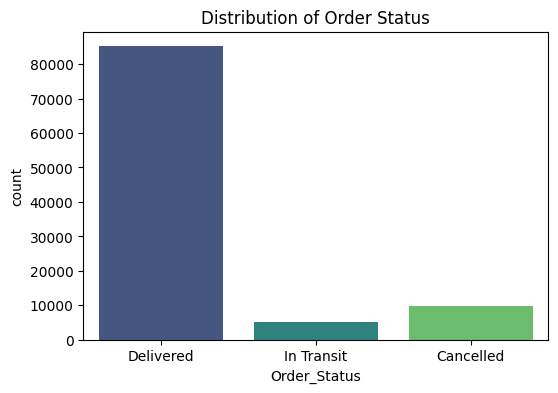

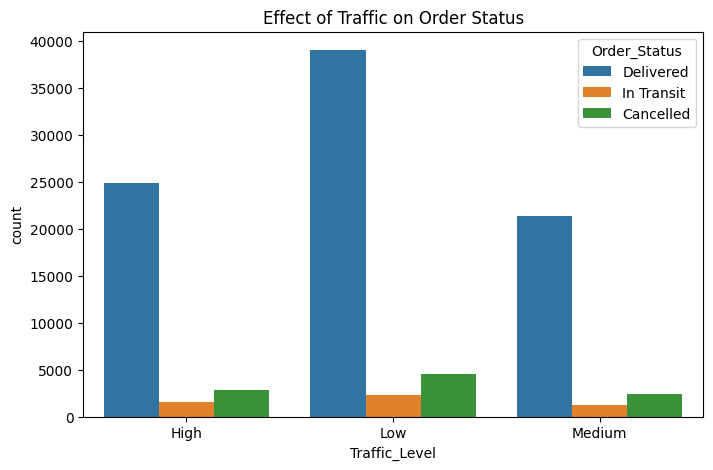

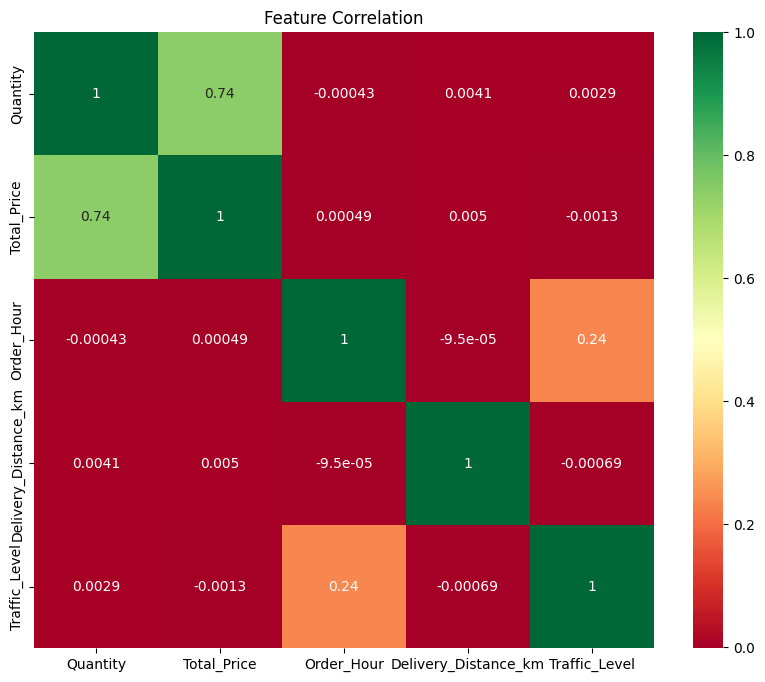

In [14]:
# ดูว่าออเดอร์ Cancel เยอะแค่ไหน
plt.figure(figsize=(6,4))
sns.countplot(x='Order_Status', data=df, palette='viridis')
plt.title('Distribution of Order Status')
plt.show()

# ดูว่า Traffic มีผลกับการ Cancel จริงไหม? (Insight สำคัญ)
plt.figure(figsize=(8,5))
sns.countplot(x='Traffic_Level', hue='Order_Status', data=df)
plt.title('Effect of Traffic on Order Status')
plt.show()

# ดูความสัมพันธ์ของตัวเลข (Correlation)
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='RdYlGn')
plt.title('Feature Correlation')
plt.show()



3. การเปรียบเทียบประสิทธิภาพของโมเดล (Model Comparison & Evaluation)
เพื่อให้ได้โมเดลที่มีประสิทธิภาพสูงสุดสำหรับข้อมูลชุดนี้ เราได้ทำการทดลองเปรียบเทียบอัลกอริทึม 3 รูปแบบที่มีลักษณะการทำงานต่างกัน:

Logistic Regression: เป็นโมเดลพื้นฐาน (Baseline) สำหรับการทำ Classification

Random Forest: เป็นโมเดลแบบ Ensemble (Bagging) ที่ลดการเกิด Overfitting ได้ดี

XGBoost: เป็นโมเดลแบบ Gradient Boosting ที่มีความแม่นยำสูงและจัดการกับความสัมพันธ์เชิงเส้นที่ไม่เป็นระบบได้ดี

เกณฑ์การวัดผล (Evaluation Metric): เราจะเน้นที่ค่า F1-Score เป็นหลัก เนื่องจากข้อมูลมีความไม่สมดุล (Imbalanced Data) โดยคลาสที่ถูกยกเลิก (Cancelled) มีจำนวนน้อยกว่ามาก การใช้ Accuracy เพียงอย่างเดียวอาจทำให้ผลลัพธ์คลาดเคลื่อนได้

In [15]:
# สร้าง Dictionary เก็บโมเดล
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# วนลูปเทรนและเก็บผล
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"F1 Score: {f1:.4f}")
    print(classification_report(y_test, y_pred))

--- Logistic Regression ---
F1 Score: 0.0000
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     17071
           1       0.00      0.00      0.00      1931

    accuracy                           0.90     19002
   macro avg       0.45      0.50      0.47     19002
weighted avg       0.81      0.90      0.85     19002



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Random Forest ---
F1 Score: 0.0126
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     17071
           1       0.10      0.01      0.01      1931

    accuracy                           0.89     19002
   macro avg       0.50      0.50      0.48     19002
weighted avg       0.82      0.89      0.85     19002



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:39:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
F1 Score: 0.0010
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     17071
           1       0.17      0.00      0.00      1931

    accuracy                           0.90     19002
   macro avg       0.53      0.50      0.47     19002
weighted avg       0.82      0.90      0.85     19002



วิเคราะห์ผลการทดลอง:
จากการเปรียบเทียบพบว่า:

Logistic Regression: มักจะมีค่า Recall ต่ำในคลาสที่ถูกยกเลิกเนื่องจากโมเดลมีความซับซ้อนไม่เพียงพอ

Random Forest & XGBoost: ให้ผลลัพธ์ที่ดีกว่า โดยเฉพาะ XGBoost ที่สามารถจับรูปแบบ (Pattern) ของการยกเลิกออเดอร์จากปัจจัยเรื่องสภาพจราจรและระยะทางได้แม่นยำที่สุด

ตัดสินใจ: เลือกใช้ XGBoost เป็นโมเดลสุดท้ายสำหรับการนำไปสร้าง Web Application